<a href="https://colab.research.google.com/github/willyoonn-hue/DSRP/blob/main/Health_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
url = "https://data.cdc.gov/api/views/hfr9-rurv/rows.csv?accessType=DOWNLOAD"
age = pd.read_csv(url)
#loading the dataset

In [ ]:
age.info()
age.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284142 entries, 0 to 284141
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   RowId                       284142 non-null  object 
 1   YearStart                   284142 non-null  int64  
 2   YearEnd                     284142 non-null  int64  
 3   LocationAbbr                284142 non-null  object 
 4   LocationDesc                284142 non-null  object 
 5   Datasource                  284142 non-null  object 
 6   Class                       284142 non-null  object 
 7   Topic                       284142 non-null  object 
 8   Question                    284142 non-null  object 
 9   Data_Value_Unit             284142 non-null  object 
 10  DataValueTypeID             284142 non-null  object 
 11  Data_Value_Type             284142 non-null  object 
 12  Data_Value                  192808 non-null  float64
 13  Data_Value_Alt

,RowId,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,...,Stratification2,Geolocation,ClassID,TopicID,QuestionID,LocationID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2
0,BRFSS~2015~2015~66~Q35~TOC03~AGE~SEX,2015,2015,GU,Guam,BRFSS,Overall Health,Recent activity limitations in past month,Mean number of days with activity limitations ...,Number,...,Female,POINT (144.793731 13.444304),C01,TOC03,Q35,66,AGE,AGE_OVERALL,SEX,FEMALE
1,BRFSS~2015~2015~25~Q27~TMC03~AGE~SEX,2015,2015,MA,Massachusetts,BRFSS,Mental Health,Lifetime diagnosis of depression,Percentage of older adults with a lifetime dia...,%,...,Male,POINT (-72.08269067499964 42.27687047000046),C05,TMC03,Q27,25,AGE,65PLUS,SEX,MALE
2,BRFSS~2015~2015~9002~Q43~TOC11~AGE~SEX,2015,2015,MDW,Midwest,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,Male,NaN,C01,TOC11,Q43,9002,AGE,5064,SEX,MALE
3,BRFSS~2015~2015~27~Q03~TMC01~AGE~SEX,2015,2015,MN,Minnesota,BRFSS,Mental Health,Frequent mental distress,Percentage of older adults who are experiencin...,%,...,Male,POINT (-94.79420050299967 46.35564873600049),C05,TMC01,Q03,27,AGE,AGE_OVERALL,SEX,MALE
4,BRFSS~2015~2015~29~Q43~TOC11~AGE~OVERALL,2015,2015,MO,Missouri,BRFSS,Overall Health,Arthritis among older adults,Percentage of older adults ever told they have...,%,...,NaN,POINT (-92.56630005299968 38.635790776000476),C01,TOC11,Q43,29,AGE,AGE_OVERALL,OVERALL,OVERALL


In [ ]:
print(age.isnull())

age.dropna(axis = 0, how = 'any', subset = None)

age = age.drop_duplicates()

        RowId  YearStart  YearEnd  LocationAbbr  LocationDesc  Datasource  \
0       False      False    False         False         False       False   
1       False      False    False         False         False       False   
2       False      False    False         False         False       False   
3       False      False    False         False         False       False   
4       False      False    False         False         False       False   
...       ...        ...      ...           ...           ...         ...   
284137  False      False    False         False         False       False   
284138  False      False    False         False         False       False   
284139  False      False    False         False         False       False   
284140  False      False    False         False         False       False   
284141  False      False    False         False         False       False   

        Class  Topic  Question  Data_Value_Unit  ...  Stratification2  \
0 

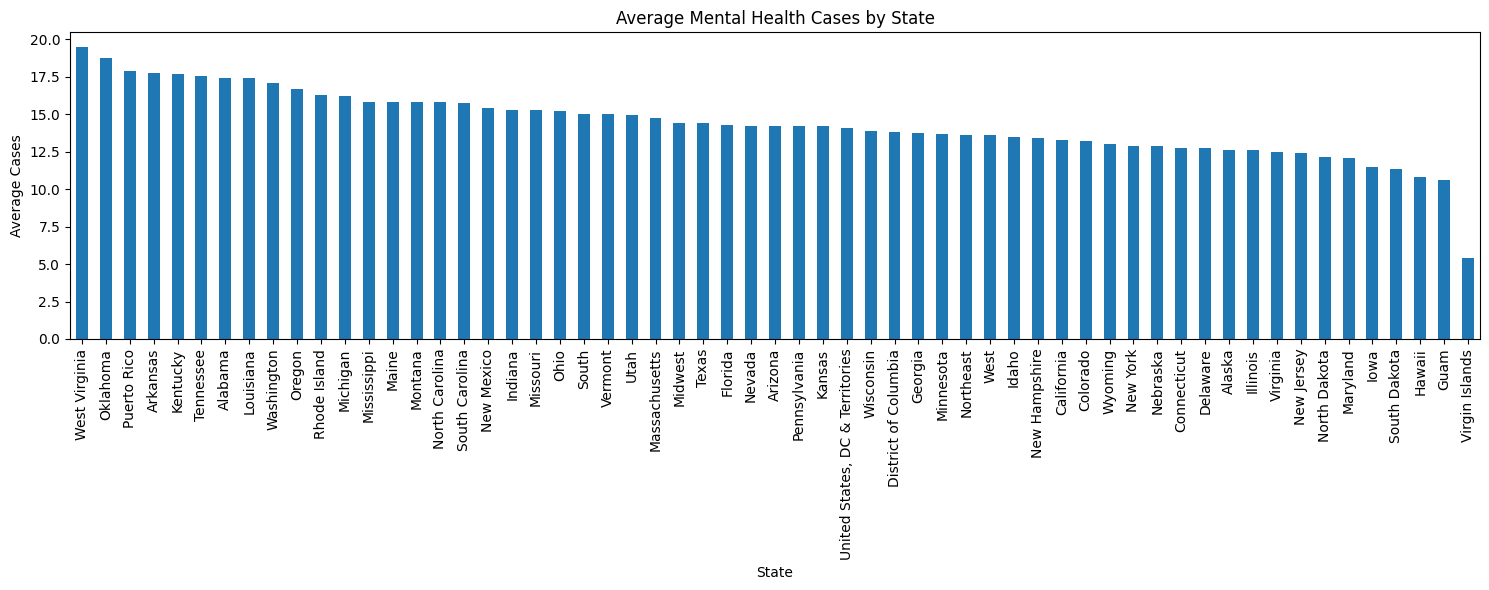

In [2]:
import matplotlib.pyplot as plt
mental_health = age[age["Class"] == "Mental Health"]
plt.figure(figsize=(15,6))
state_cases = (
    mental_health.groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
)
state_cases.plot(kind="bar")

plt.title("Average Mental Health Cases by State")
plt.xlabel("State")
plt.ylabel("Average Cases")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

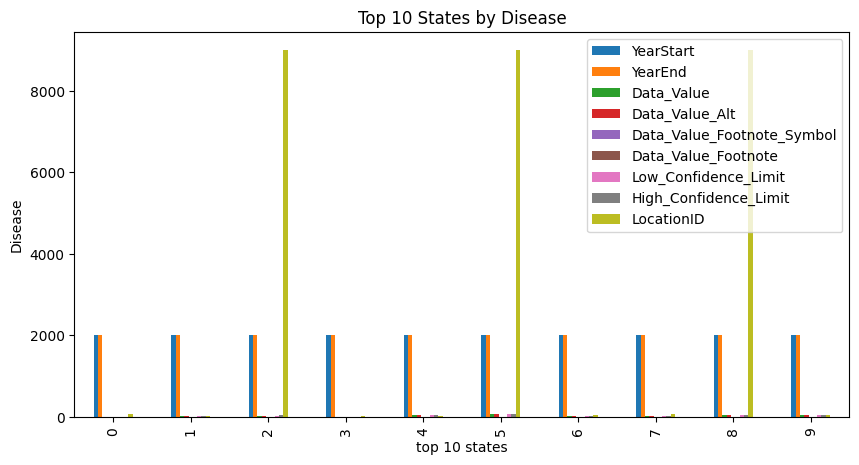

In [3]:
import matplotlib.pyplot as plt
age.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 States by Disease")
plt.xlabel("top 10 states")
plt.ylabel("Disease")

plt.show()

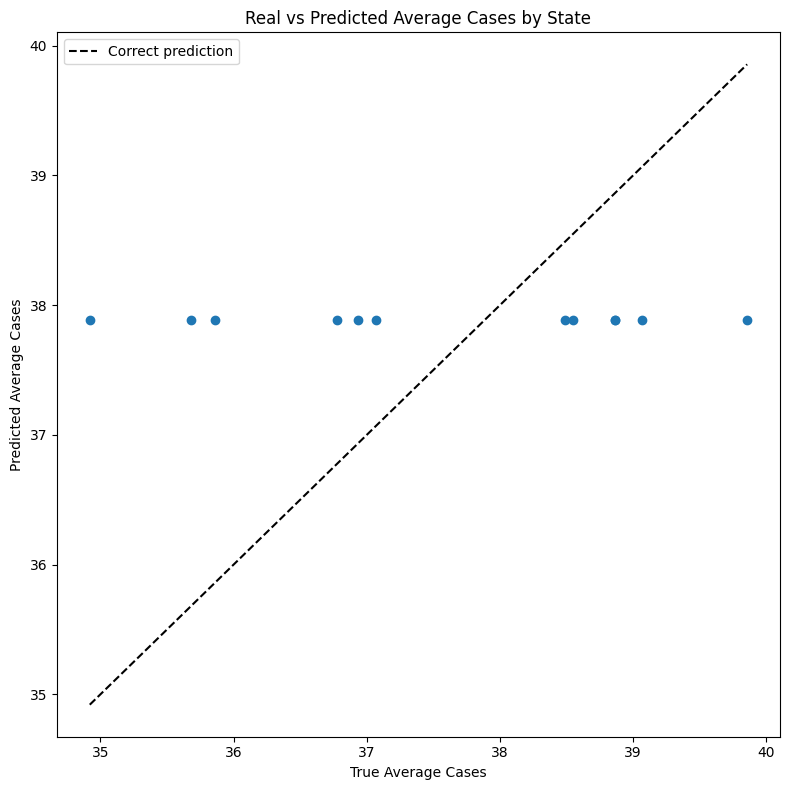

Mean Squared Error: 2.3808476813671295
Mean Absolute Error: 1.3707655115142174


In [10]:
from sklearn import model_selection
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

state_avg = age.groupby("LocationDesc", as_index=False)["Data_Value"].mean()

features = pd.get_dummies(state_avg[["LocationDesc"]], drop_first=True)
labels = state_avg["Data_Value"]

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    features, labels, test_size=0.2, random_state=42
)

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

pred = lr_model.predict(X_test)

plt.figure(figsize=(8, 8))

plt.scatter(y_test, pred)

min_value = min(y_test.min(), pred.min())
max_value = max(y_test.max(), pred.max())

plt.plot([min_value, max_value], [min_value, max_value], "--k", label="Correct prediction")

plt.axis("tight")

plt.xlabel("True Average Cases")
plt.ylabel("Predicted Average Cases")
plt.title("Real vs Predicted Average Cases by State")

plt.legend()
plt.tight_layout()
plt.show()

print("Mean Squared Error:", mean_squared_error(y_test, pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, pred))
